In [2]:
from openpiv import tools, pyprocess, validation, filters, scaling, piv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [105]:
from scipy.io import loadmat
from scipy.interpolate import griddata

def load_clean_piv_displacement(file):
    mat_data = loadmat(file)
    u_piv = mat_data["u_original"]
    v_piv = -mat_data["v_original"]
    x = mat_data["x"]
    y = mat_data["y"]
    # h_piv = np.zeros((2, 1, *u_piv.shape), dtype=u_piv.dtype)

    # h_piv[1, 0] = u_piv
    # h_piv[0, 0] = v_piv

    return u_piv, v_piv, x, y

In [135]:
def get_dense_piv_displacement(file, img):
    
    mat_data = loadmat(file)
    u_piv = mat_data["u_original"]
    v_piv = -mat_data["v_original"]
    x = mat_data["x"]
    y = mat_data["y"]
    
    x_flat = np.nan_to_num(x.flatten(), nan=0.0)
    y_flat = np.nan_to_num(y.flatten(), nan=0.0)
    u_flat = np.nan_to_num(u_piv.flatten(), nan=0.0)
    v_flat = np.nan_to_num(v_piv.flatten(), nan=0.0)

    img_h, img_w = img[0].shape
    
    xi = np.linspace(x.min(), x.max(), img_w)
    yi = np.linspace(y.min(), y.max(), img_h)
    xi_grid, yi_grid = np.meshgrid(xi, yi)

    u_dense = griddata((x_flat, y_flat), u_flat, (xi_grid, yi_grid), method='cubic')
    v_dense = griddata((x_flat, y_flat), v_flat, (xi_grid, yi_grid))
    
    h_piv = np.zeros((2,) + (img.shape[0],) + img.shape[1:])        
    h_piv[0, 0] = u_dense
    h_piv[1, 0] = v_dense             
            
    return h_piv

In [137]:
def rmse(u: np.ndarray, h: np.ndarray) -> float:
    """
    Computes the Root Mean Square Error (RMSE) between two vector fields.

    Args:
        u (np.ndarray):
            Ground-truth field, shape `(d, H, W, ...)`.
        h (np.ndarray):
            Estimated or predicted field, same shape as `u`.

    Returns:
        float:
            The root mean square error value between `u` and `h`.
    """
    diff = u - h
    mse = np.mean(diff**2)
    return np.sqrt(mse)

In [156]:
img_path = '/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_100.0_E_500.0_nu_0.45/im_00_cell_003_img.npy'
ugt_path = '/Users/josephinelahmani/Desktop/ofmeca_elas/data/elas/experiment_1/T_100.0_E_500.0_nu_0.45/im_00_cell_003_ugt.npy'
dir = Path('/Users/josephinelahmani/Desktop/ofmeca_elas/data/fine_tuning')

images = np.load(img_path)
disp_gt = np.load(ugt_path)
mask = disp_gt[0, 0] != 0
norm_disp = np.sqrt(np.mean(disp_gt**2))

for file in sorted(dir.rglob("*.mat")):
    h_piv = get_dense_piv_displacement(
        dir / file, images
    )
    h_piv_mask = h_piv * mask
    rmse_flow_piv = rmse(h_piv_mask, disp_gt) / norm_disp

    print("params:", file.name)
    print("rmse dis:", rmse_flow_piv)

params: int_ar_24_pass_12_step_8.mat
rmse dis: 1.093680826376404
params: int_ar_32_pass_12_step_8.mat
rmse dis: 1.1054792568701104
params: int_ar_32_pass_16_step_10.mat
rmse dis: 1.1025673954316237
params: int_ar_32_pass_16_step_12.mat
rmse dis: 1.1052794384876172
params: int_ar_32_pass_16_step_8.mat
rmse dis: 1.109016391831451
params: int_ar_32_pass_24_12_step_8.mat
rmse dis: 1.1154340487435204
params: smoothness_20.mat
rmse dis: 1.2055100314342495
params: smoothness_30.mat
rmse dis: 1.207220806192345
params: smoothness_40.mat
rmse dis: 1.2044727418525156
params: smoothness_50.mat
rmse dis: 1.1866063435171166
params: smoothness_60.mat
rmse dis: 1.148313166823327


In [ ]:
file_path = Path('/Users/josephinelahmani/Desktop/ofmeca_elas/data/fine_tuning/int_ar_24_pass_12_step_8.mat')

h_piv = get_dense_piv_displacement(file_path, images)

In [151]:
mat_data = loadmat(file_path)

mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'calxy', 'calu', 'calv', 'units', 'u_original', 'v_original', 'x', 'y', 'typevector_original', 'u_filtered', 'v_filtered', 'typevector_filtered', 'u_smoothed', 'v_smoothed', 'information'])

(232.0, 0.0)

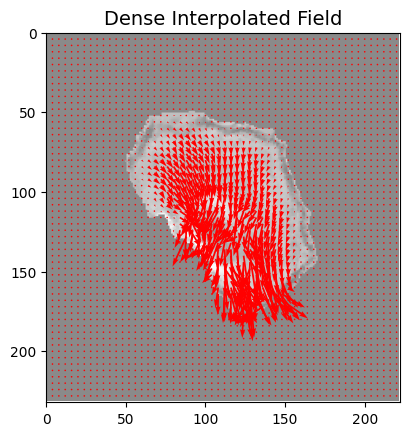

In [146]:
fig, ax = plt.subplots(1, 1)
h, w = h_piv.shape[2:]
y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
ax.imshow(images[0], cmap='gray', alpha=0.5, origin='upper')
skip = 4 
ax.quiver(x_dense[::skip, ::skip], y_dense[::skip, ::skip], 
          h_piv[0, 0, ::skip, ::skip], h_piv[1, 0, ::skip, ::skip], 
          scale=50, color='r', width=0.005)
ax.set_title('Dense Interpolated Field', fontsize=14)
ax.set_xlim(0, w)
ax.set_ylim(h, 0)

In [75]:
from scipy.interpolate import griddata

def inverse_transform_coordinates(x, y, u, v):
    """Revert physical coordinates back to image coordinates"""
    if y.ndim == 1:
        y = y[::-1]
    else:
        y = y[::-1, :]
    return x, y, u, v

def get_dense_displacement(frame_a, frame_b, window_size=8, overlap=2, 
                           search_area=16, s2n_thresh=1.3, method='cubic'):
    """
    Get pixel-level dense displacement field
    """
    
    x, y, u, v, s2n = piv.simple_piv(
        frame_a, frame_b, 
        window_size=window_size, 
        overlap=overlap,
        search_area_size=search_area, 
        dt=1.0,
        validation_method='sig2noise', 
        plot=False
    )
    
    x, y, u, v = inverse_transform_coordinates(x, y, u, v)
    
    valid = s2n > s2n_thresh
    
    flags = validation.sig2noise_val(s2n, threshold=1.2)
    u_filtered, v_filtered = filters.replace_outliers(
        u, v, flags,
        method='localmean',
        max_iter=5,          # ↑ from 3
        kernel_size=5        # ↑ from 3
    )
    print(x.shape)
    
    x_valid = x[valid]
    y_valid = y[valid]
    u_valid = u_filtered[valid]
    v_valid = v_filtered[valid]
    
    print(x_valid.shape)
    print(y_valid.shape)
    print(u_valid.shape)
    print(v_valid.shape)
    h, w = frame_a.shape
    y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
    
    print(x_dense.shape)
    print(y_dense.shape)
    
    u_dense = griddata((x_valid, y_valid), u_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    v_dense = griddata((x_valid, y_valid), v_valid, (x_dense, y_dense), 
                       method=method, fill_value=0)
    
    u_dense = np.nan_to_num(u_dense, nan=0.0)
    v_dense = np.nan_to_num(v_dense, nan=0.0)
    
    return u_dense, v_dense, (x, y, u, v, valid, s2n)

In [76]:
# Get dense field
u_dense, v_dense, sparse_results = get_dense_displacement(
    frame_a_norm, frame_b_norm,
    window_size=16,
    overlap=8,   
    search_area=24, 
    s2n_thresh=1.2,
)

(14, 13)
(62,)
(62,)
(62,)
(62,)
(232, 222)
(232, 222)


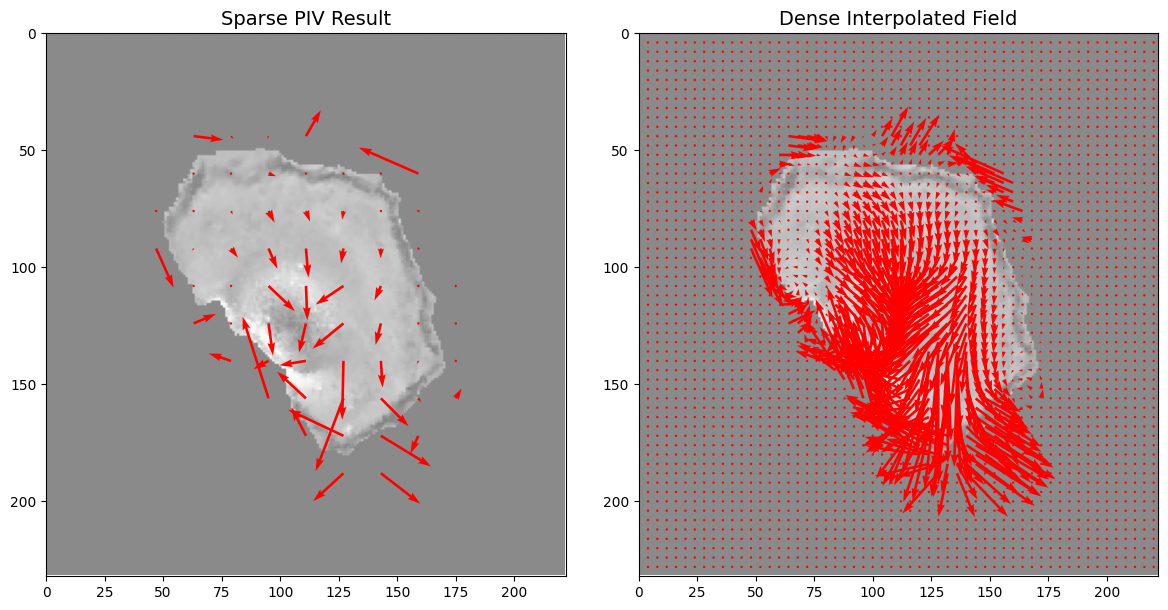

6.76321128726487 11.0


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Sparse PIV
x, y, u, v, valid, s2n = sparse_results

ax = axes[0]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
ax.quiver(x[valid], y[valid], u[valid], v[valid], scale=70, color='r', width=0.005)
ax.set_title('Sparse PIV Result', fontsize=14)
ax.set_xlim(0, frame_a_norm.shape[1])
ax.set_ylim(frame_a_norm.shape[0], 0)

# Dense interpolated
ax = axes[1]
h, w = u_dense.shape
y_dense, x_dense = np.mgrid[0:h:1, 0:w:1]
ax.imshow(frame_a_norm, cmap='gray', alpha=0.5, origin='upper')
skip = 4 
ax.quiver(x_dense[::skip, ::skip], y_dense[::skip, ::skip], 
          u_dense[::skip, ::skip], v_dense[::skip, ::skip], 
          scale=50, color='r', width=0.005)
ax.set_title('Dense Interpolated Field', fontsize=14)
ax.set_xlim(0, w)
ax.set_ylim(h, 0)

plt.tight_layout()
plt.show()

print(u.max(), v.max())

In [ ]:
def pad_to_multiple_8(arr):
    h, w = arr.shape
    
    pad_h = (8 - h % 8) % 8  # 0 si déjà divisible
    pad_w = (8 - w % 8) % 8
    
    arr_padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode="edge")
    
    return arr_padded, h, w

def unpad_flow(flow_np, orig_h, orig_w):
    return flow_np[:, :orig_h, :orig_w]

In [67]:
from torchvision.models.optical_flow import Raft_Large_Weights, raft_large
import torch

frame_a_padded, h, w = pad_to_multiple_8(frame_a)
frame_b_padded, h, w = pad_to_multiple_8(frame_b)

# frame_a shape: (H, W) -> need (1, C, H, W)
img1 = torch.from_numpy(frame_a_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)
img2 = torch.from_numpy(frame_b_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)

img1 = img1.repeat(1, 3, 1, 1)  # (1, 3, H, W)
img2 = img2.repeat(1, 3, 1, 1)  # (1, 3, H, W)

weights = Raft_Large_Weights.DEFAULT
transforms = weights.transforms()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=False).to(device)
model = model.eval()

img1, img2 = transforms(img1, img2)

img1 = img1.to(device)
img2 = img2.to(device)

with torch.no_grad():
    list_of_flows = model(img1, img2)

predicted_flow = list_of_flows[-1]
print(predicted_flow.shape)

torch.Size([1, 2, 232, 224])


In [ ]:
def raft_algo(img: np.ndarray) -> np.ndarray:
    
    def pad_to_multiple_8(arr):
        h, w = arr.shape
        
        pad_h = (8 - h % 8) % 8
        pad_w = (8 - w % 8) % 8
        
        arr_padded = np.pad(arr, ((0, pad_h), (0, pad_w)), mode="edge")
        
        return arr_padded, h, w

    def unpad_flow(flow_np, orig_h, orig_w):
        return flow_np[:, :orig_h, :orig_w]

    frame_1_padded, h, w = pad_to_multiple_8(img[0])
    frame_2_padded, _, _ = pad_to_multiple_8(img[1])

    # frame_1 shape: (H, W) -> need (1, C, H, W)
    img1 = torch.from_numpy(frame_1_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)
    img2 = torch.from_numpy(frame_2_padded).unsqueeze(0).unsqueeze(0)  # (1, C, H, W)

    img1 = img1.repeat(1, 3, 1, 1)  # (1, 3, H, W)
    img2 = img2.repeat(1, 3, 1, 1)  # (1, 3, H, W)

    weights = Raft_Large_Weights.DEFAULT
    transforms = weights.transforms()

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = raft_large(weights=Raft_Large_Weights.DEFAULT, progress=False).to(device)
    model = model.eval()

    img1, img2 = transforms(img1, img2)

    img1 = img1.to(device)
    img2 = img2.to(device)

    with torch.no_grad():
        list_of_flows = model(img1, img2)

    predicted_flow = list_of_flows[-1]
    predicted_flow_np = predicted_flow.cpu().numpy()
    flow_np = np.transpose(unpad_flow(predicted_flow_np, h, w), (1, 0, 2, 3))
    
    return flow_np

In [77]:
predicted_flow_np = predicted_flow.cpu().numpy()
flow_np = unpad_flow(predicted_flow_np, h, w)

In [78]:
predicted_flow_np.shape

(1, 2, 232, 224)

In [75]:
flow_np.shape

(2, 1, 222, 224)

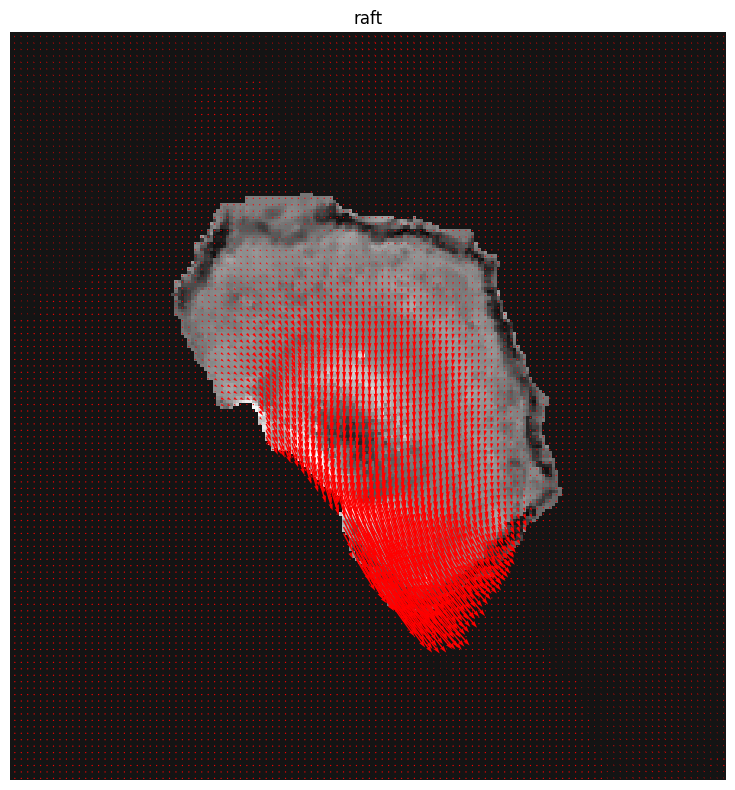

In [70]:
def plot_flow_quiver(frame, flow_np, step=16):
    """
    Affiche le flux optique sous forme de quivers sur l'image frame.
    
    Args:
        frame    : numpy array (H, W) - image de référence
        flow_np  : numpy array (2, H, W) - flux optique (u, v)
        step     : int - espacement entre les flèches (plus grand = moins de flèches)
    """
    h, w = frame.shape

    flow_u = flow_np[0]
    flow_v = flow_np[1]

    y, x = np.mgrid[step//2:h:step, step//2:w:step]

    u = flow_u[y, x]
    v = flow_v[y, x]

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(frame, cmap="gray")
    ax.quiver(
        x, y, u, v,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.002,
    )

    ax.set_title("raft")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_flow_quiver(frame_a, flow_np, step=2)

In [3]:
from pathlib import Path
import numpy as np

path_noise = Path('/Users/josephinelahmani/Desktop/ofmeca_elas/data/noise_experiment_T_100.0_E_500.0_nu_0.45/img_im_00_cell_003/std_0p50_img.npy')

img = np.load(path_noise)

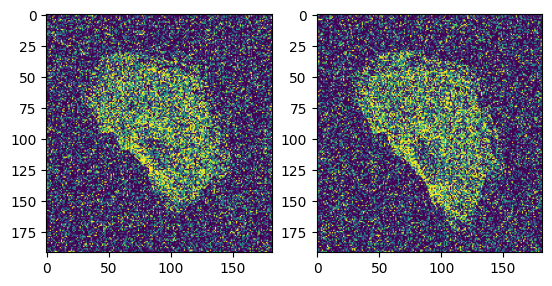

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)
axes[0].imshow(img[0])
axes[1].imshow(img[1])

In [4]:
import sys
from pathlib import Path

sys.path.append("/Users/josephinelahmani/Desktop/ofmeca_elas/mechanics")

from src.utils import load_order_clean, remap

from pathlib import Path

img, _ = load_order_clean(Path("/Users/josephinelahmani/Desktop/ofmeca/data/micro_images/250213_Overnight 50Hz 25Vpp_pos2.tif"))

img_ = img[2:4, 10, 180:430, 140:390, 1]

image = remap(img_)

ModuleNotFoundError: No module named 'mechanics'

In [8]:
import tifffile 

tifffile.imwrite("/Users/josephinelahmani/Desktop/ofmeca_elas/data_tiff/img_micro.tif", image)

In [47]:
import sys
sys.path.append("/Users/josephinelahmani/Desktop/ofmeca_elas")

import pandas as pd 
from pathlib import Path

path_dfs = Path("/Users/josephinelahmani/Desktop/ofmeca_elas/results/tables_dict")

In [48]:
dfs = []
for exp in [1, 2, 3]:
    df = pd.read_csv(path_dfs / f"mean_rmse_experiment_{exp}.csv")

    # 2. Nettoyer le DataFrame pour qu'il ressemble à l'original
    # a) Si les noms de méthodes sont dans une colonne (pas l'index)
    if "Unnamed: 0" in df.columns:  # Si l'index a été sauvegardé comme colonne
        df = df.set_index("Unnamed: 0")  # Met les noms de méthodes dans l'index

    # b) Si les noms de colonnes ont changé (ex: "RMSE displacement" → "RMSE displacement ")
    df.columns = df.columns.str.strip()  # Enlève les espaces en trop

    # c) Convertir tout en numérique (au cas où)
    df = df.apply(pd.to_numeric, errors='coerce')

    dfs.append(df)

In [85]:
import importlib 
import mechanics.src.plot_functions
importlib.reload(mechanics.src.plot_functions)
from mechanics.src.plot_functions import save_scatter_comparison

results_dir = "/Users/josephinelahmani/Desktop/ofmeca_elas/results"

save_scatter_comparison(dfs, Path(results_dir))

/Users/josephinelahmani/Desktop/ofmeca_elas/mechanics/src/plot_functions.py:385: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  def save_table_rmse(rmse_table: pd.DataFrame, save_path: Path):
